In [ ]:
'''
2025년 9월 9일 집에 들어온 뒤에 다시 공부를 시작했습니다. 화이팅!!!
'''

2


In [ ]:
'''
import warnings
# 경고창 제거
warnings.filterwarnings('ignore')
# 한글 글꼴 설정
rc('font', family='Malgun Gothic')
'''

## 시각화 과정에서 한글을 사용해보면 한글이 깨지며 무수한 경고들이 나오는 것을 볼 수 있다.
## 이를 방지하기 위해 강의에서는 위와 같은 폰트를 예시로 제시했으나,
## 나는 모든 경고를 무력화하는 것이 불안해 아래의 코드를 작성했다.

import matplotlib.pyplot as plt
import warnings
import pandas as pd

# 1. 선별적 경고 무시
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')
warnings.filterwarnings('ignore', message='.*font.*')

# 2. 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 3. 중요한 경고는 여전히 볼 수 있음
print("현재 경고 필터:", warnings.filters[:3])  # 설정된 필터 확인

현재 경고 필터: [('ignore', re.compile('.*font.*', re.IGNORECASE), <class 'Warning'>, None, 0), ('ignore', None, <class 'FutureWarning'>, re.compile('pandas'), 0), ('ignore', re.compile('numpy.ndarray size changed', re.IGNORECASE), <class 'Warning'>, None, 0)]


# 머신러닝 지도학습 AI모델링

In [ ]:

'''
지도학습은 입력값과 출력값이 있는 데이터를 인공지능에게 학습시키는 방법이다.

이번 챕터에서 배울 머신러닝 지도학습 :

회귀 모델
1. 선형회귀 (중요)

분류 모델
1. 로지스틱 회귀 (중요)
2. KNN
3. SVM (Support Vector Machine)

회귀 및 분류 모두
1. 의사결정나무 (중요)

1. 앙상블
1. 랜덤포레스트, 
1. 그래디언트 부스팅

및 모델간 성능 비교이다.
'''

## 0. 사이킷런 라이브러리 (sklearn)

In [ ]:
'''
Scikit learn은 파이썬의 가장 대표적인 라이브러리로, 
간단한 api를 통해 데이터 전처리, 모델링, 평가 등 
머신러닝의 전 과정을 수행할 수 있다.
'''

In [ ]:
pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


## <B> 1. 회귀

### <b> 1-1. 선형회귀 - 무조건 나온다고 가정하고 공부하자!!

In [ ]:
'''
y = ax + b 의 직선 형태를 가정하고 회귀선을 찾는 방법이다.
나에게도 재무관리에서 익숙하게 사용한 방법론이라 익숙하다.

선형회귀에서의 손실함수는
평균제곱오차 (Mean Squared Error, MSE)
평균절대오차 (Mean Absolute Error, MAE)
허브 손실 (Huber Loss)
로그 코시 손실 (Log-Cosh Loss)

등이 있으며, MSE와 MAE를 주로 사용한다.
'''

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score ## MSE, MAE, 결정계수(예측성능 - 통계학적 개념의 독립변수의 종속변수에 대한 설명력이 아님)

In [ ]:
data = pd.read_csv('datasets/winequality-white.csv')

print(data.head)
print(data.shape)
print(data.columns)

<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.0              0.27         0.36            20.7      45.00   
1               6.3              0.30         0.34             1.6      49.00   
2               8.1              0.28         0.40             6.9       0.05   
3               7.2              0.23         0.32             8.5      58.00   
4               7.2              0.23         0.32             8.5      58.00   
...             ...               ...          ...             ...        ...   
4893            6.2              0.21         0.29             1.6      39.00   
4894            6.6              0.32         0.36             8.0      47.00   
4895            6.5              0.24         0.19             1.2      41.00   
4896            5.5              0.29         0.30             1.1      22.00   
4897            6.0              0.21         0.38             0.8       0.02  

In [ ]:
x_data = data.drop(['quality', 'alcohol'], axis=1)      ## 독립변수 설정
print(x_data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      45.00   
1            6.3              0.30         0.34             1.6      49.00   
2            8.1              0.28         0.40             6.9       0.05   
3            7.2              0.23         0.32             8.5      58.00   
4            7.2              0.23         0.32             8.5      58.00   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  
0                 45.0                 170.0    1.001  3.00       0.45  
1                 14.0                 132.0  994.000  3.30       0.49  
2                 30.0                  97.0    9.951  3.26       0.44  
3                 47.0                 186.0    9.956  3.19       0.40  
4                 47.0                 186.0    9.956  3.19       0.40  


In [ ]:
y_data = data['quality']        ## 종속변수 설정
print(y_data.head())

0    6
1    6
2    6
3    6
4    6
Name: quality, dtype: int64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state = 1)

model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_prediction = model.predict(x_test)

In [ ]:
MSE = mean_squared_error(y_test, y_prediction)
MAE = mean_absolute_error(y_test, y_prediction)
r2  = r2_score(y_test, y_prediction)

print(MSE)
print(MAE)
print(r2)

0.6696386754771485
0.636792427165119
0.09979930010714522


In [ ]:
'''
라쏘, 릿지, 엘라스틱 넷 코드들

from sklearn.linear_model import Lasso
model = Lasso(alpha=0.1)                    ## l1 정규화 - 뻴걸 빼버리기
model.fit(x_train, y_train)

from sklearn.linear_model import Ridge
model = Ridge(alpha=0.1)                    ## l2 정규화 - 변수간 조정
model.fit(x_train, y_train)

from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio = 0.5)     # L1과 L2 혼합
model.fit(x_train, y_train)
'''

In [ ]:
from sklearn.linear_model import Lasso
model = Lasso(alpha=0.1)                    ## l1 정규화 - 뻴걸 빼버리기
model.fit(x_train, y_train)
y_prediction = model.predict(x_test)

MSE = mean_squared_error(y_test, y_prediction)
MAE = mean_absolute_error(y_test, y_prediction)
r2  = r2_score(y_test, y_prediction)

print(MSE)
print(MAE)
print(r2)

0.6811328995645217
0.6370504690370352
0.08434752148816715


In [ ]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=0.1)                    ## l2 정규화 - 변수간 조정
model.fit(x_train, y_train)
y_prediction = model.predict(x_test)

MSE = mean_squared_error(y_test, y_prediction)
MAE = mean_absolute_error(y_test, y_prediction)
r2  = r2_score(y_test, y_prediction)

print(MSE)
print(MAE)
print(r2)

0.6696323712631934
0.6367847617823931
0.09980777491307036


In [ ]:
from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio = 0.5)     # L1과 L2 혼합
model.fit(x_train, y_train)
y_prediction = model.predict(x_test)

MSE = mean_squared_error(y_test, y_prediction)
MAE = mean_absolute_error(y_test, y_prediction)
r2  = r2_score(y_test, y_prediction)

print(MSE)
print(MAE)
print(r2)

0.6775237828324027
0.637183120895011
0.08919928636858354


## <b> 2. 분류

### <b> 2-1. 로지스틱 회귀 - 이것도 시험 단골문제!!

In [ ]:
'''
로지스틱 회귀는 분류 문제를 해결하는 머신러닝 알고리즘이다. 
이름에 '회귀'가 들어가지만, 실제로는 데이터를 여러 클래스로 분류하는 데 사용된다.

선형 회귀와의 차이점
선형 회귀는 연속적인 값을 예측하며 (예: 집 가격, 온도)
로지스틱 회귀는 확률을 예측하여 분류한다 (예: 스팸/정상 메일, 합격/불합격)

로지스틱 회귀의 핵심은 시그모이드 함수이다
σ(z) = 1 / (1 + e^(-z))
이 함수는 어떤 실수 값이든 0과 1 사이의 값으로 변환하며, 
확률로 해석할 수 있게 된다.

장점
간단하고 빠른 학습
확률적 해석 가능
과적합이 잘 발생하지 않음
선형적으로 분리 가능한 데이터에 효과적

단점
비선형 관계를 잘 포착하지 못함
이상치에 민감
독립변수 간 다중공선성 문제

실제 활용 예시
이메일 스팸 필터링
의료 진단 (질병 유무)
마케팅 (고객 구매 예측)
금융 (대출 승인/거부)
'''

#### 시그모이드 함수

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))     # 시그모이드 정의 σ(z) = 1 / (1 + e^(-z))

In [ ]:
z = np.linspace(-10, 10, 100)

Text(0.5, 1.0, '시그모이드 함수')

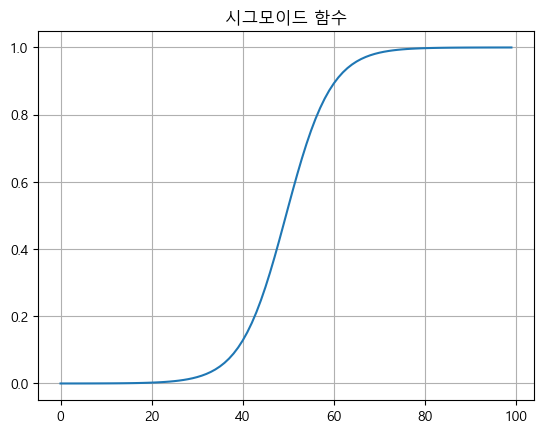

In [ ]:
sigmoid_value = sigmoid(z)

plt.plot(sigmoid_value)
plt.grid()
plt.title('시그모이드 함수')

#### 로지스틱 회귀

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split        # 테스트셋 분할
from sklearn.linear_model    import LogisticRegression      # 로지스틱 회귀 모델
from sklearn.metrics         import accuracy_score, confusion_matrix    # 분류모델 평가

In [ ]:
data = pd.read_csv('datasets/heart.csv')

print(data.head())
print(data.shape)

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  
(303, 14)


In [ ]:
x = data.drop(['output'], axis=1)   # 독립변수
y = data['output']                  # 종속변수

print(x.head())
print('\n',y.head(), sep = '')

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  
0    0      1  
1    0      2  
2    0      2  
3    0      2  
4    0      2  

0    1
1    1
2    1
3    1
4    1
Name: output, dtype: int64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=2)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(212, 13)
(91, 13)
(212,)
(91,)


In [ ]:
model = LogisticRegression(max_iter= 10000)    # model 설정 - 로지스틱 회귀
                                              # max_iter : 최대 반복횟수
model.fit(x_train, y_train)                   # 모델 학습

# penalty = 'l1' / 'l2' / 'elasticnet' / 'none' - 정규화 유형
# C = 1.0     정규화 강도 (작을수록 강함)
# solver = '' 최적화 알고리즘
# max_iter =  학습 반복횟수
# random_state = 난수 고정

LogisticRegression(max_iter=10000)

In [ ]:
y_prediction = model.predict(x_test)          # x테스트셋으로 y 예측테스트셋 도출

print(accuracy_score(y_prediction, y_test))
print('\n',confusion_matrix(y_prediction, y_test),sep='')

0.8681318681318682

[[31  2]
 [10 48]]


### <b> 2-2. KNN

In [ ]:
'''
KNN은 K-최근접 이웃 알고리즘
새로운 데이터가 들어왔을 때 가장 가까운 K개의 이웃들을 찾아
그들의 정보를 바탕으로 예측하는 알고리즘 - 분류와 회귀 모두 가능!


작동 원리
1. 새로운 데이터 포인트가 주어짐
2. 모든 학습 데이터와의 거리를 계산
3. 가장 가까운 K개의 이웃을 선택
4. 이웃들의 정보를 바탕으로 예측

분류: 다수결 투표
회귀: 평균값 계산


K 값의 의미
K = 1: 가장 가까운 1개의 이웃만 고려
K = 3: 가장 가까운 3개의 이웃 고려
K = 5: 가장 가까운 5개의 이웃 고려


거리 측정 방법
유클리드 거리 (가장 일반적):
d = √[(x₁-x₂)² + (y₁-y₂)²]
맨하탄 거리:
d = |x₁-x₂| + |y₁-y₂|
인코프스키 거리


K가 너무 작으면 (K=1):
노이즈에 민감
과적합 위험

K가 너무 크면:
경계가 너무 부드러워짐
과소적합 위험

일반적 가이드라인:
K = √(데이터 개수) 정도로 시작
홀수 선택 (동점 방지)
교차 검증으로 최적값 찾기


장점:
이해하기 쉽고 직관적
가정이 없음 (non-parametric)
분류와 회귀 모두 가능
새로운 데이터에 즉시 적응

단점:
계산 비용이 높음 (모든 거리 계산)
차원의 저주에 취약
메모리 사용량이 많음
특성 스케일링이 중요
'''

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = pd.read_csv('datasets/heart.csv')

print(data.head())

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [ ]:
x = data.drop(['output'], axis =1 )
y = data['output']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state=3)

In [ ]:
scaler = StandardScaler()
 
x_train_scaled = scaler.fit_transform(x_train)      ## 학습 집단에 fit 되어있기 때문에 아래 실험집단엔 다시 fit 하지 않는다
x_test_scaled = scaler.transform(x_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors= 5)  # K값을 5로 설정
knn.fit(x_train_scaled, y_train)

y_prediction = knn.predict(x_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_prediction))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_prediction))
print("Classification Report:\n", classification_report(y_test, y_prediction))

Accuracy: 0.8351648351648352
Confusion Matrix:
 [[29  9]
 [ 6 47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.76      0.79        38
           1       0.84      0.89      0.86        53

    accuracy                           0.84        91
   macro avg       0.83      0.82      0.83        91
weighted avg       0.83      0.84      0.83        91



### <b> 2-3. SVM - Support Vector Machine

In [ ]:
'''
분류와 회귀 문제를 해결하는 지도학습 알고리즘
핵심 아이디어는 클래스 간의 경계(결정 경계)를 최대한 멀리 떨어뜨리는 것

Margin과 Support Vector
    ○ ○     |     × ×
  ○     ○   |   ×     ×
    ○ ○     |     × ×
           경계선

Margin: 결정 경계와 가장 가까운 데이터 포인트들 사이의 거리
Support Vector: 경계선에 가장 가까운 데이터 포인트들
목표: Margin을 최대화하는 경계선 찾기

장점:
고차원 데이터에서 효과적
메모리 효율적 (support vector만 저장)
다양한 커널로 유연성 높음
Overfitting에 상대적으로 강함

단점:
대용량 데이터에서 느림
확률 정보 제공 안함
하이퍼파라미터 튜닝 필요
노이즈에 민감
'''

In [ ]:
import pandas as pd
import numpy  as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.svm             import SVC
from sklearn.metrics         import accuracy_score, classification_report, confusion_matrix

In [ ]:
# 데이터 불러오기
data = pd.read_csv("datasets/heart.csv")

# x, y 분리
x = data.drop(columns=["output"])  # 'output' 열을 제외한 나머지를 X로 설정
y = data["output"]  # 'output' 열을 타겟 변수로 설정

# 훈련 데이터와 테스트 데이터 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 정규화 - StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)  # 훈련 데이터 기준으로 스케일링 적용
x_test_scaled = scaler.transform(X_test)  # 동일한 스케일 적용

In [ ]:
svm_model = SVC(kernel= 'linear', random_state= 4)  # 선형 커널
svm_model.fit(x_train_scaled, y_train)              # 학습

# 커널 변경 (linear, poly, rbf, sigmoid)
# C 값 변경 (정규화 강도 조절)
# 감마 값 변경 (gamma)
# 확률 예측 활성화 (probability=True)

SVC(kernel='linear', random_state=4)

In [ ]:
y_predict = svm_model.predict(x_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict))
print("Classification Report:\n", classification_report(y_test, y_predict))

Accuracy: 0.8688524590163934
Confusion Matrix:
 [[25  4]
 [ 4 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



## <b> 3. 회귀와 분류 모두 가능한 모델들

### <b> 3-1. 의사결정나무 (중요!!!)

In [ ]:
'''
if-else 규칙을 트리 구조로 만들어 분류나 회귀를 수행하는 알고리즘
사람의 의사결정 과정과 매우 유사해 해석이 쉽다는 것이 가장 큰 장점

날씨가 맑은가?
├── 예 → 온도가 25도 이상인가?
│         ├── 예 → 야외활동 (분류 결과)
│         └── 아니오 → 실내활동
└── 아니오 → 실내활동


노드의 종류
루트 노드: 맨 위 시작점
내부 노드: 조건을 나타내는 노드
리프 노드: 최종 예측 결과 


분할 기준

분류용 (Classification):
지니 불순도 (Gini Impurity): Gini = 1 - Σ(pi)²
엔트로피 (Entropy): Entropy = -Σ(pi × log2(pi))
    - 어떠한 기준으로 나눴을 때 지니 지수가 작아지는지 (순수한 집단이 되는지를 시행착오법으로 파악)

회귀용 (Regression):
평균제곱오차 (MSE): MSE = Σ(yi - ŷ)²/n
'''

In [ ]:
import pandas as pd
data = pd.read_csv('datasets/heart.csv')

print(data.head())
print('\n', data.shape, sep='')

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

(303, 14)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree            import DecisionTreeClassifier
from sklearn.metrics         import accuracy_score, classification_report, confusion_matrix

In [ ]:
x = data.drop(['output'],axis=1)
y = data['output']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state= 12)

In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_predict = model.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_test, y_predict)
confu = confusion_matrix(y_test, y_predict)
report = classification_report(y_test, y_predict)

print(accuracy, confu, report, sep='\n')

0.6923076923076923
[[31 14]
 [14 32]]
              precision    recall  f1-score   support

           0       0.69      0.69      0.69        45
           1       0.70      0.70      0.70        46

    accuracy                           0.69        91
   macro avg       0.69      0.69      0.69        91
weighted avg       0.69      0.69      0.69        91



In [ ]:
DecisionTreeClassifier?

'''
DecisionTreeClassifier(
    *,
    criterion='gini',                    # 분할 품질 측정 기준: 'gini'(지니불순도) or 'entropy'(엔트로피)
    splitter='best',                     # 분할 전략: 'best'(최적분할) or 'random'(무작위분할)
    max_depth=None,                      # 트리의 최대 깊이 (None=제한없음, 과적합 방지용)
    min_samples_split=2,                 # 노드를 분할하기 위한 최소 샘플 수
    min_samples_leaf=1,                  # 리프 노드에 있어야 하는 최소 샘플 수
    min_weight_fraction_leaf=0.0,        # 리프 노드 최소 가중치 비율 (가중치 샘플링 시 사용)
    max_features=None,                   # 분할 시 고려할 최대 특성 수 (None=모든특성, 'sqrt', 'log2', 정수)
    random_state=None,                   # 재현 가능한 결과를 위한 난수 시드
    max_leaf_nodes=None,                 # 리프 노드의 최대 개수 (None=제한없음)
    min_impurity_decrease=0.0,           # 분할을 수행하기 위한 최소 불순도 감소량
    class_weight=None,                   # 클래스별 가중치 ('balanced' 또는 딕셔너리 형태)
    ccp_alpha=0.0,                       # 최소비용복잡도 가지치기 파라미터 (클수록 더 많이 가지치기)
    monotonic_cst=None,                  # 단조성 제약조건 (특성이 증가할 때 예측의 증감 방향 제한)
)
'''

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None

### <b> 3-2. 앙상블

In [ ]:
'''
앙상블의 기본 원리는 "여러 명의 의견이 한 명의 의견보다 정확할 가능성이 높다"는 것
각각의 모델이 서로 다른 실수를 한다면, 이들을 결합했을 때 개별 모델의 오류가 상쇄되어 
전체적으로 더 나은 성능을 얻을 수 있음


주요 기법

보팅(Votting) - 다른 모델, 동일 샘플
서로 다른 유형의 모델을 결합하여 결과를 결정
결합 예시: 로지스틱 회귀 + 의사결정 나무 + 서포트 벡터 머신 
    하드 보팅   : 모델들의 예측 결과를 다수결 투표로 취합
    소프트 보팅 : 각 모델이 예측한 결과를 평균 내어 가장 높은 확률의 클래스 선택


배깅(Bagging) - 동일 모델, 다른 샘플
동일한 모델을 여러 번 학습시키되, 각각 다른 데이터 샘플을 사용
대표적인 예: Random Forest
분산(variance)을 줄이는 효과

부스팅(Boosting)
모델들을 순차적으로 학습시키되
이전 모델이 실수한 부분에 가중치를 부여해 다음 모델을 학습시키는 방법 
대표적인 예: AdaBoost, Gradient Boosting, XGBoost

    Ada Boost
        틀린 샘플에 가중치 부여
    Gradient Boosting
        잔차를 최소화하는 방향으로 순차학습
    XG Boost (Extreme Gradient Boosting)
        GB 개선
    LightGBM (Light Gradient Boosting Machine)
        XG 성능개선
    CatBoost
        원-핫 인코딩 없이 범주형 데이터 처리 가능

스태킹(Stacking)
서로 다른 알고리즘들의 예측을 입력으로 받아 최종 예측을 만드는 메타 모델 사용
가장 복잡하지만 강력한 성능

장점
개별 모델보다 일반적으로 더 높은 정확도
과적합 위험 감소
모델의 안정성 향상

단점
계산 비용 증가
해석하기 어려움
더 많은 메모리 필요
'''

In [ ]:
pip install xgboost

In [ ]:
pip install lightgbm

In [ ]:
pip install catboost

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.ensemble     import VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost              import XGBClassifier
from lightgbm             import LGBMClassifier
from catboost             import CatBoostClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.svm          import SVC
from sklearn.metrics      import accuracy_score, classification_report,confusion_matrix

In [3]:
data = pd.read_csv('datasets/heart.csv')

print(data.head())
print(data.shape)

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  
(303, 14)


In [5]:
x = data.drop(['output'], axis=1)
y = data['output']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state= 23)

#### 3-2-1. 보팅 - 같은 샘플, 다른 모델

In [13]:
model = LogisticRegression(max_iter=1000)
model2= DecisionTreeClassifier()
model3= SVC(probability=True)

In [14]:
voting = VotingClassifier(estimators=[('logistic',model),
                                      ('decision_tree',model2),
                                      ('svc',model3)],
                          voting= 'soft')

voting.fit(x_train, y_train)

VotingClassifier(estimators=[('logistic', LogisticRegression(max_iter=1000)),
                             ('decision_tree', DecisionTreeClassifier()),
                             ('svc', SVC(probability=True))],
                 voting='soft')

In [ ]:
'''
estimators: 투표에 참여할 개별 모델들의 리스트

('logistic', model): 로지스틱 회귀 모델
('decision_tree', model2): 의사결정트리 모델
('svc', model3): SVM 분류 모델
각 튜플의 첫 번째 요소는 모델 이름, 두 번째는 실제 모델 객체


voting='soft': 투표 방식 설정

'soft': 각 모델의 예측의 확률평균으로 최종 예측 결정
'hard': 각 모델의 예측 클래스를 직접 투표하여 다수결로 결정
'''

In [15]:
y_prediction = voting.predict(x_test)

In [19]:
accuracy = accuracy_score(y_test, y_prediction)
confu = confusion_matrix(y_test, y_prediction)
report = classification_report(y_test, y_prediction)

print(accuracy, confu, report, sep='\n')

0.7582417582417582
[[33 11]
 [11 36]]
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        44
           1       0.77      0.77      0.77        47

    accuracy                           0.76        91
   macro avg       0.76      0.76      0.76        91
weighted avg       0.76      0.76      0.76        91



#### 3-2-2. 배깅 - 다른 샘플(일부분 중첩되는), 같은 모델

In [20]:
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(),
                            n_estimators= 10,           ## 몇개의 샘플로 나눠서 학습시킬지
                            random_state= 24)

In [21]:
bagging.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=24)

In [26]:
y_predict = bagging.predict(x_test)

In [27]:
accuracy = accuracy_score(y_test, y_predict)
confu = confusion_matrix(y_test, y_predict)
report = classification_report(y_test, y_predict)

print(accuracy, confu, report, sep='\n')

0.7692307692307693
[[32 12]
 [ 9 38]]
              precision    recall  f1-score   support

           0       0.78      0.73      0.75        44
           1       0.76      0.81      0.78        47

    accuracy                           0.77        91
   macro avg       0.77      0.77      0.77        91
weighted avg       0.77      0.77      0.77        91



#### 3-2-3. 부스팅 - 순차학습, 이전 오류에 가중치 부여

In [25]:
boosting = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                             n_estimators=50,
                             random_state=25
)

NameError: name 'AdaBoostClassifier' is not defined

In [29]:
boosting.fit(x_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=4),
                   random_state=25)

In [30]:
y_prediction = boosting.predict(x_test)

In [31]:
accuracy = accuracy_score(y_test, y_prediction)
confu = confusion_matrix(y_test, y_prediction)
report = classification_report(y_test, y_prediction)

print(accuracy, confu, report, sep='\n')

0.8131868131868132
[[32 12]
 [ 5 42]]
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        44
           1       0.78      0.89      0.83        47

    accuracy                           0.81        91
   macro avg       0.82      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91



### <b> 3-2. 랜덤 포레스트 - 배깅의 일종 (출제 확률 높음!)

In [ ]:
'''
여러 개의 의사결정나무(Decision Tree)를 결합해 더 정확하고 안정적인 예측을 하는 방법
일정 부분 중복되는 샘플들을 Decision Tree 모델에 학습시키는 방식으로,
크게 보아 배깅의 일종임

기본 원리
이름처럼, Random Forest는 많은 의사결정나무들을 만들어서 그들의 예측을 종합
마치 여러 전문가의 의견을 들어보고 최종 결정을 내리는 것과 유사

작동 방식
Bootstrap Sampling : 원본 데이터에서 복원추출로 여러 개의 훈련 데이터셋을 만듭니다
Feature Randomness : 각 나무를 만들 때 전체 특성(feature) 중 일부만 랜덤하게 선택합니다
Tree Building      : 각각의 샘플된 데이터와 선택된 특성으로 의사결정나무를 학습합니다
Voting/Averaging   : 분류 - 각 나무의 예측 결과를 투표로 결정
                     회귀 - 각 나무의 예측값을 평균내어 최종 예측


주요 장점
Feature importance : 각 변수가 모델에 얼마나 기여했는지를 계산해 변수의 기여도를 산출해줌
과적합 방지: 단일 의사결정나무보다 일반화 성능이 좋습니다
안정성     : 노이즈나 이상치에 덜 민감합니다
특성 중요도: 어떤 변수가 예측에 중요한지 알 수 있습니다
사용 편의성: 하이퍼파라미터 튜닝이 상대적으로 쉽습니다

주요 단점
해석성     : 개별 의사결정나무보다 모델 해석이 어렵습니다
메모리 사용: 많은 나무를 저장해야 해서 메모리를 많이 사용합니다
예측 시간  : 여러 나무의 예측을 종합해야 해서 단일 모델보다 느립니다

중요한 파라미터
n_estimators     : 생성할 나무의 개수
max_depth        : 각 나무의 최대 깊이
max_features     : 각 분할에서 고려할 특성의 개수
min_samples_split: 노드를 분할하기 위한 최소 샘플 수
'''

In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics      import accuracy_score, classification_report,confusion_matrix
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('datasets/heart.csv')

print(data.head(), data.shape, sep='\n')

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  
(303, 14)


In [10]:
x = data.drop(['output'],axis=1)
y = data['output']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state= 27)

In [12]:
model = RandomForestClassifier(n_estimators=1000,    # 트리 개수(기본 100)
                               criterion='gini',    # 불순도 측정 (gini or entropy)
                               max_depth=None,      # 트리 최대 깊이
                               min_samples_split=2, # 노드 분할의 최소 샘플 수
                               min_samples_leaf=1,  # 리프 노드가 가져야 할 최소 샘플
                               max_features='sqrt', # 트리 분할시 최대 특성 개수
                               bootstrap=True,      # 배깅 방식 적용 여부
                               oob_score=True,      # Out Of Bag 샘플로 정확도 평가 여부
                               n_jobs=1,            # 병렬 처리 여부
                               random_state=28,
                               verbose=1            # 학습 과정 출력 여부
                               )

In [ ]:
'''
n_estimators=100

생성할 의사결정나무의 개수
많을수록 성능이 좋아지지만 계산 시간도 증가
일반적으로 100~1000 사이에서 설정

criterion='gini'

노드 분할 시 불순도를 측정하는 기준
'gini': 지니 불순도 (기본값, 계산이 빠름)
'entropy': 엔트로피 (정보 이득 기반, 더 정확할 수 있음)

트리 구조 제어
max_depth=None

각 트리의 최대 깊이 제한
None: 제한 없음 (모든 리프가 순수하거나 min_samples_split보다 적을 때까지)
숫자 지정 시: 과적합 방지에 도움

min_samples_split=2

노드를 분할하기 위한 최소 샘플 수
2보다 크게 설정하면 과적합 방지
너무 크면 언더피팅 위험

min_samples_leaf=1

리프 노드가 가져야 할 최소 샘플 수
1보다 크게 설정하면 더 일반화된 모델
과적합 방지에 효과적

특성 선택
max_features='sqrt'

각 분할에서 고려할 최대 특성 개수
'sqrt': 전체 특성 수의 제곱근 (분류의 기본값)
'log2': 전체 특성 수의 log2
정수: 구체적인 개수 지정
None: 모든 특성 사용

앙상블 방법
bootstrap=True

부트스트랩 샘플링 사용 여부
True: 복원추출로 각 트리마다 다른 훈련 데이터 사용
False: 전체 데이터셋을 모든 트리가 사용

oob_score=True

Out-of-Bag 점수 계산 여부
부트스트랩으로 선택되지 않은 샘플로 검증
별도 검증 데이터 없이도 모델 성능 평가 가능

실행 환경
n_jobs=1

병렬 처리할 프로세서 개수
1: 단일 프로세서 사용
-1: 모든 프로세서 사용
숫자: 지정한 개수만큼 사용

random_state=28

랜덤 시드 고정으로 재현 가능한 결과
같은 값이면 항상 동일한 결과
실험의 일관성을 위해 설정

verbose=1

학습 과정 출력 수준
0: 출력 없음
1: 진행 상황 출력
2: 더 자세한 출력

성능 튜닝 팁

성능 향상: n_estimators 증가, max_features 조정
과적합 방지: max_depth 제한, min_samples_split/leaf 증가
속도 개선: n_jobs=-1로 병렬 처리, n_estimators 감소
'''

In [13]:
model.fit(x_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.7s


RandomForestClassifier(n_estimators=1000, n_jobs=1, oob_score=True,
                       random_state=28, verbose=1)

In [15]:
y_pred = model.predict(x_test)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s


In [18]:
accuracy = accuracy_score(y_test, y_pred)
confu = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(accuracy, confu, report, sep='\n')

0.8351648351648352
[[37  5]
 [10 39]]
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        42
           1       0.89      0.80      0.84        49

    accuracy                           0.84        91
   macro avg       0.84      0.84      0.84        91
weighted avg       0.84      0.84      0.84        91



[0.10230195 0.03972989 0.11662159 0.07870167 0.08344205 0.0087092
 0.02138911 0.1512236  0.05425195 0.09472851 0.04675909 0.10500511
 0.09713628]


<BarContainer object of 13 artists>

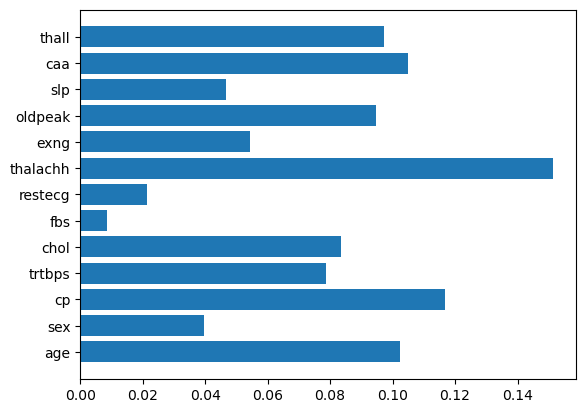

In [24]:
## 랜덤 포레스트에만 존재하는 특성 중요도
feature_importance = model.feature_importances_
features = x.columns

print(feature_importance)
plt.barh(features, feature_importance)

### <b> 3-3. 그래디언트 부스팅 - 잔차 최소화 순차학습

In [ ]:
'''
그래디언트 부스팅은 약한 학습기(weak learner)들을 순차적으로 학습시켜
강한 모델을 만드는 부스팅 기법

- gradient(기울기)를 계속 조정하며 핛ㅂ

각 단계에서 이전 모델의 오차를 줄이는 방향으로 새로운 모델을 학습


작동 원리
초기 예측: 단순한 초기값(보통 평균값)으로 시작
잔차 계산: 실제값과 현재 예측값의 차이(잔차) 계산
새 모델 학습: 잔차를 예측하도록 새로운 약한 학습기 훈련
예측 업데이트: 기존 예측에 새 모델의 예측을 더함
반복: 설정한 횟수만큼 2-4단계 반복


장점:
높은 예측 성능
과적합에 상대적으로 강함
다양한 손실 함수 사용 가능
특성 중요도 제공

단점:
학습 시간이 오래 걸림
하이퍼파라미터 튜닝이 복잡
순차적 학습으로 병렬화 어려움


AdaBoost는 틀린 샘플에 가중치를 증가 - 이전 모델이 틀린 데이터를 학습
GradientBoost는 잔차를 학습해 보완   - 새로운 모델이 잔차를 예측해 최소화
'''

In [5]:
import pandas as pd
from sklearn.ensemble        import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, confusion_matrix, classification_report

In [6]:
data = pd.read_csv('datasets/heart.csv')

x = data.drop(['output'], axis = 1)
y = data['output']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state= 29)

model = AdaBoostClassifier(n_estimators=5,
                           learning_rate=1.0,
                           random_state=49)

In [7]:
model.fit(x_train, y_train)

AdaBoostClassifier(n_estimators=5, random_state=49)

In [10]:
## Gradient Boost
gb_clf = GradientBoostingClassifier(n_estimators=5,
                                    learning_rate=0.1,
                                    max_depth=2)

gb_clf.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=2, n_estimators=5)

In [11]:
ada_pred = model.predict(x_test)

gb_pred = gb_clf.predict(x_test)

In [13]:
ada_acc = accuracy_score(y_test, ada_pred)
gb_acc  = accuracy_score(y_test, gb_pred)

print(ada_acc, gb_acc, sep='\n')

0.8241758241758241
0.8461538461538461
